In [2]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv(r'C:\Users\LENOVO\Desktop\machine learning\100_days_of_ML\day_38_num+catagorical_both\train.csv', usecols=['Age', 'Fare', 'Survived'])

In [4]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [5]:
df.isnull().mean()*100

Survived     0.00000
Age         19.86532
Fare         0.00000
dtype: float64

In [6]:
x = df.drop(columns='Survived')
y = df['Survived']

In [7]:
X_train,X_test,y_train,y_test = train_test_split(x,y,test_size = 0.2 , random_state = 2)

In [8]:
X_train

,Age,Fare
30,40.0,27.7208
10,4.0,16.7000
873,47.0,9.0000
182,9.0,31.3875
876,20.0,9.8458
...,...,...
534,30.0,8.6625
584,NaN,8.7125
493,71.0,49.5042
527,NaN,221.7792


In [9]:
X_train['Age_imputed'] = X_train['Age']
X_test['Age_imputed'] = X_test['Age']

In [10]:
X_test.tail()

,Age,Fare,Age_imputed
89,24.0,8.0500,24.0
80,22.0,9.0000,22.0
846,NaN,69.5500,NaN
870,26.0,7.8958,26.0
251,29.0,10.4625,29.0


In [11]:
X_train.loc[X_train['Age_imputed'].isnull(), 'Age_imputed'] = X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values
X_test.loc[X_test['Age_imputed'].isnull(), 'Age_imputed'] = X_train['Age'].dropna().sample(X_test['Age'].isnull().sum()).values

In [12]:
X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values

array([29. , 28. , 14. , 59. , 36. , 30. , 30. , 32. , 21. , 50. ,  5. ,
        9. , 19. , 20. , 20. , 32. , 22. , 20. ,  4. , 19. , 27. , 28. ,
       23.5, 31. , 61. , 29. , 27. , 32.5, 45. ,  1. , 29. ,  2. , 40.5,
       22. , 29. , 16. , 38. , 62. , 11. , 31. , 27. , 58. , 35. ,  9. ,
        9. , 23. , 18. , 27. , 17. , 42. , 14. , 24. , 34. , 42. , 24. ,
       18. ,  9. , 26. , 29. , 40.5, 17. , 43. , 36. , 18. , 26. , 50. ,
       29. , 19. , 65. , 14.5,  3. , 32. ,  6. , 22. , 22. , 71. , 34. ,
       39. , 49. ,  5. , 22. , 27. , 48. , 47. , 31. , 24. , 22. , 16. ,
       36. , 34. , 40. , 31. ,  8. ,  6. , 24. ,  4. , 18. , 70.5, 37. ,
       19. , 38. , 26. , 21. , 51. , 18. , 58. , 33. , 28. , 42. , 52. ,
       47. , 18. , 27. ,  9. , 24. , 32. , 42. , 45. , 15. , 26. , 34. ,
       34. , 21. , 24. , 11. , 19. , 25. , 49. ,  4. , 28.5,  2. , 28. ,
       33. , 25. , 39. , 27. , 18. , 33. , 45. , 45. , 25. , 46. , 56. ,
        2. , 20. , 30. , 33. , 44. ])

In [13]:
X_train['Age'].isnull().sum()

np.int64(148)

In [14]:
X_train

,Age,Fare,Age_imputed
30,40.0,27.7208,40.0
10,4.0,16.7000,4.0
873,47.0,9.0000,47.0
182,9.0,31.3875,9.0
876,20.0,9.8458,20.0
...,...,...,...
534,30.0,8.6625,30.0
584,NaN,8.7125,18.0
493,71.0,49.5042,71.0
527,NaN,221.7792,33.0


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_12696\3805712594.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Age'],label = 'original' , hist = False)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_12696\3805712594.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(

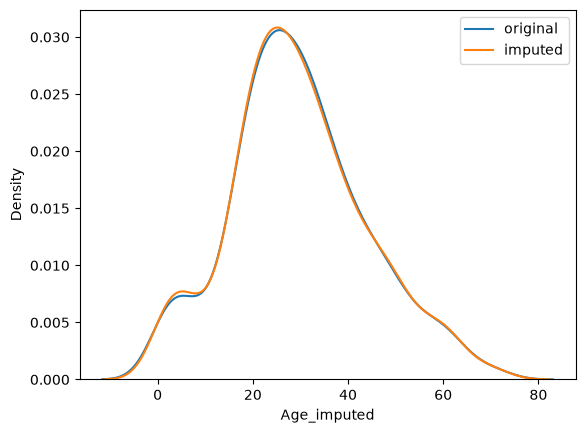

In [15]:
sns.distplot(X_train['Age'],label = 'original' , hist = False)
sns.distplot(X_train['Age_imputed'],label = 'imputed' , hist = False)

plt.legend()
plt.show()

In [16]:
print('original variance :' ,X_train['Age'].var())
print('imputed variance :', X_train['Age_imputed'].var())

original variance : 204.34951339046142
imputed variance : 205.9681889283965


In [17]:
X_train[['Fare','Age','Age_imputed']].cov()

,Fare,Age,Age_imputed
Fare,2368.246832,71.512440,59.378822
Age,71.512440,204.349513,204.349513
Age_imputed,59.378822,204.349513,205.968189


<Axes: >

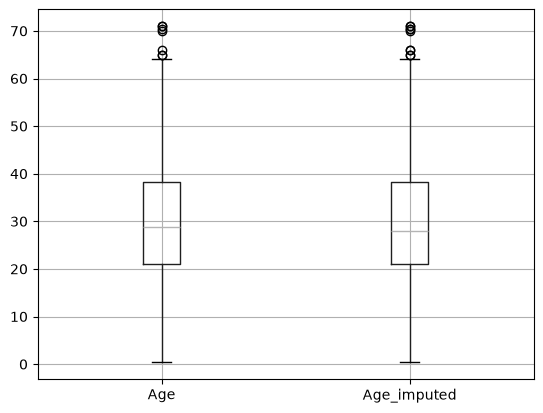

In [18]:
X_train[['Age','Age_imputed']].boxplot()

In [19]:
sampled_value = X_train['Age'].dropna().sample(1, random_state=int(observation['Fare']))

NameError: name 'observation' is not defined

In [21]:


data = pd.read_csv(
    r'C:\Users\LENOVO\Desktop\machine learning\100_days_of_ML\day_38_num+catagorical_both\house-train.csv',
    usecols=['GarageQual', 'FireplaceQu', 'SalePrice']
)

In [22]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [23]:
data.isnull().mean() * 100

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

In [24]:
X = data
y = data['SalePrice']

In [25]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [26]:
X_train['GarageQual_imputed'] = X_train['GarageQual']
X_test['GarageQual_imputed'] = X_test['GarageQual']

X_train['FireplaceQu_imputed'] = X_train['FireplaceQu']
X_test['FireplaceQu_imputed'] = X_test['FireplaceQu']

In [27]:
X_train.sample(5)

,FireplaceQu,GarageQual,SalePrice,GarageQual_imputed,FireplaceQu_imputed
1420,TA,TA,179900,TA,TA
1071,NaN,TA,154000,TA,NaN
1184,TA,TA,186700,TA,TA
1176,NaN,TA,119500,TA,NaN
884,NaN,TA,100000,TA,NaN


In [44]:
for column in ['GarageQual', 'FireplaceQu']:
	imputed_column = f'{column}_imputed'

	train_missing = X_train[column].isna()
	test_missing = X_test[column].isna()

	X_train.loc[train_missing, imputed_column] = (
		X_train.loc[X_train[column].notna(), column]
		.sample(n=train_missing.sum())
		.to_numpy()
	)

	X_test.loc[test_missing, imputed_column] = (
		X_train.loc[X_train[column].notna(), column]
		.sample(n=test_missing.sum())
		.to_numpy()
	)

In [45]:
temp = pd.concat(
        [
            X_train['GarageQual'].value_counts() / len(X_train['GarageQual'].dropna()),
            X_train['GarageQual_imputed'].value_counts() / len(X_train)
        ],
        axis=1)

temp.columns = ['original', 'imputed']

In [46]:
temp

,original,imputed
TA,0.951043,0.950342
Fa,0.037171,0.038527
Gd,0.009973,0.009418
Po,0.000907,0.000856
Ex,0.000907,0.000856


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_12696\1827688635.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[X_train['FireplaceQu'] == category]['SalePrice'],hist=False,label=category)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_12696\1827688635.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed297445

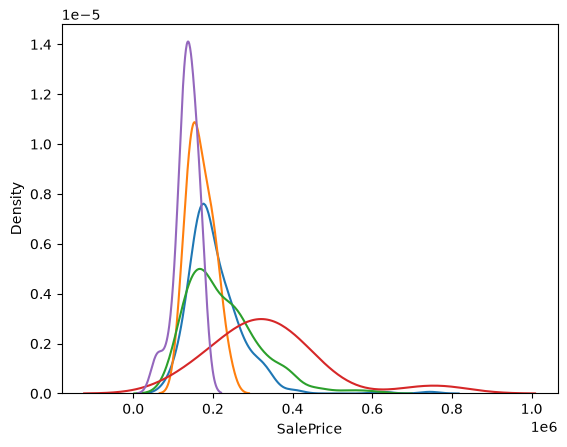

In [47]:
for category in X_train['FireplaceQu'].dropna().unique():
    sns.distplot(X_train[X_train['FireplaceQu'] == category]['SalePrice'],hist=False,label=category)
plt.show()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_12696\722808554.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[X_train['FireplaceQu_imputed'] == category]['SalePrice'],hist=False,label=category)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_12696\722808554.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed

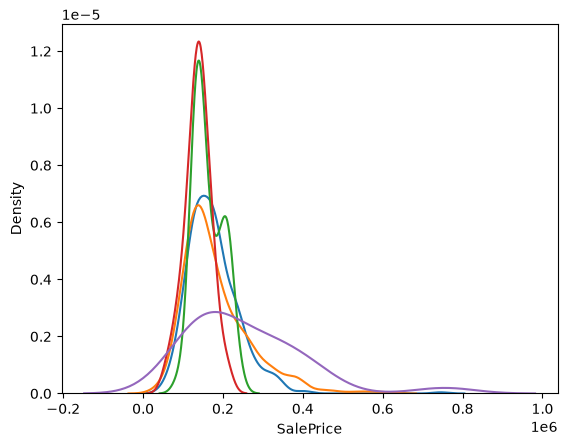

In [48]:
for category in X_train['FireplaceQu_imputed'].dropna().unique():
    sns.distplot(X_train[X_train['FireplaceQu_imputed'] == category]['SalePrice'],hist=False,label=category)
plt.show()